# 🎧 Cluster Audio Explorer & Manual Labeling

**เป้าหมาย**: ฟังเสียง audio จากแต่ละ cluster แล้ว label เป็น song type จริงๆ

## Workflow
```
cluster ID → ดึง representative segments → play audio → เปรียบกับ literature → label
```

## Reference: Cricket Song Types (Gryllus bimaculatus)

| Song Type | Acoustic Signature | Context |
|-----------|-------------------|---------|
| 🟢 **Calling Song** | Regular chirp pulses, moderate RMS, low ZCR | ดึงดูด female ระยะไกล |
| 🔴 **Aggressive Song** | Irregular bursts, HIGH RMS, high ZCR | ต่อสู้แย่งอาณาเขต/อาหาร |
| 🔵 **Courtship Song** | Soft, continuous trill, very LOW RMS | เกี้ยวพาราสี female ระยะใกล้ |
| ⚪ **Stridulation/Other** | Broadband, variable | friction noise, อื่นๆ |

> **Reference**: Alexander, R.D. (1961). *Aggressiveness, territoriality, and sexual behavior in field crickets*. Behaviour, 17(2-3), 130-223.

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import librosa
import librosa.display
import IPython.display as ipd
import pickle
import json
from pathlib import Path
from ipywidgets import widgets, HBox, VBox, Output
from IPython.display import display, clear_output

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a', 'axes.facecolor': '#0f0f1a',
    'axes.edgecolor': '#333355', 'axes.labelcolor': '#ccccee',
    'text.color': '#ccccee', 'xtick.color': '#aaaacc', 'ytick.color': '#aaaacc',
})

RESULTS  = Path('../results')
WAV_ROOT = Path('../dataset/insectset32/Orthoptera/Orthoptera')
SR       = 22050
SEG_DUR  = 2.5   # seconds per segment

# ── Load data ─────────────────────────────────────────────────────────────────
df   = pd.read_csv(RESULTS / 'segments_with_clusters.csv')
pipe = pickle.load(open(RESULTS / 'cluster_pipeline.pkl', 'rb'))
X    = np.load('../features_cache/features_X.npy')

embedding = pipe.embedding_
labels    = pipe.labels_

# Feature column indices
RMS_COLS = slice(48, 52)
ACI_COL  = 52
ZCR_COL  = 47   # last col of Chroma+ZCR block

all_cluster_ids = sorted([c for c in df['cluster'].unique() if c >= 0])

# ── Precompute per-cluster stats ───────────────────────────────────────────────
cluster_stats = {}
for cid in all_cluster_ids:
    mask = df['cluster'] == cid
    idxs = df.index[mask].tolist()
    feat  = X[idxs]
    cluster_stats[cid] = {
        'count':       int(mask.sum()),
        'rms_mean':    float(feat[:, RMS_COLS].mean()),
        'aci_mean':    float(feat[:, ACI_COL].mean()),
        'zcr_mean':    float(feat[:, ZCR_COL].mean()),
        'dom_species': df[mask]['species'].value_counts().index[0],
        'dom_purity':  df[mask]['species'].value_counts().iloc[0] / mask.sum(),
        'indices':     idxs,
    }

# ── Load / init label store ────────────────────────────────────────────────────
LABEL_FILE = RESULTS / 'cluster_manual_labels.json'
if LABEL_FILE.exists():
    manual_labels = json.loads(LABEL_FILE.read_text())
    manual_labels = {int(k): v for k, v in manual_labels.items()}
    print(f' Loaded existing labels: {len(manual_labels)} clusters already labeled')
else:
    manual_labels = {}
    print(' Starting fresh — no labels saved yet')

print(f'\n {len(all_cluster_ids)} clusters to label | {len(df)} total segments')

 Starting fresh — no labels saved yet

 37 clusters to label | 759 total segments


## 1️⃣ ภาพรวม: RMS vs ZCR ของทุก Cluster

ใช้ scatter นี้ดูว่า cluster ไหนน่าสนใจ (outlier = characteristic song type)

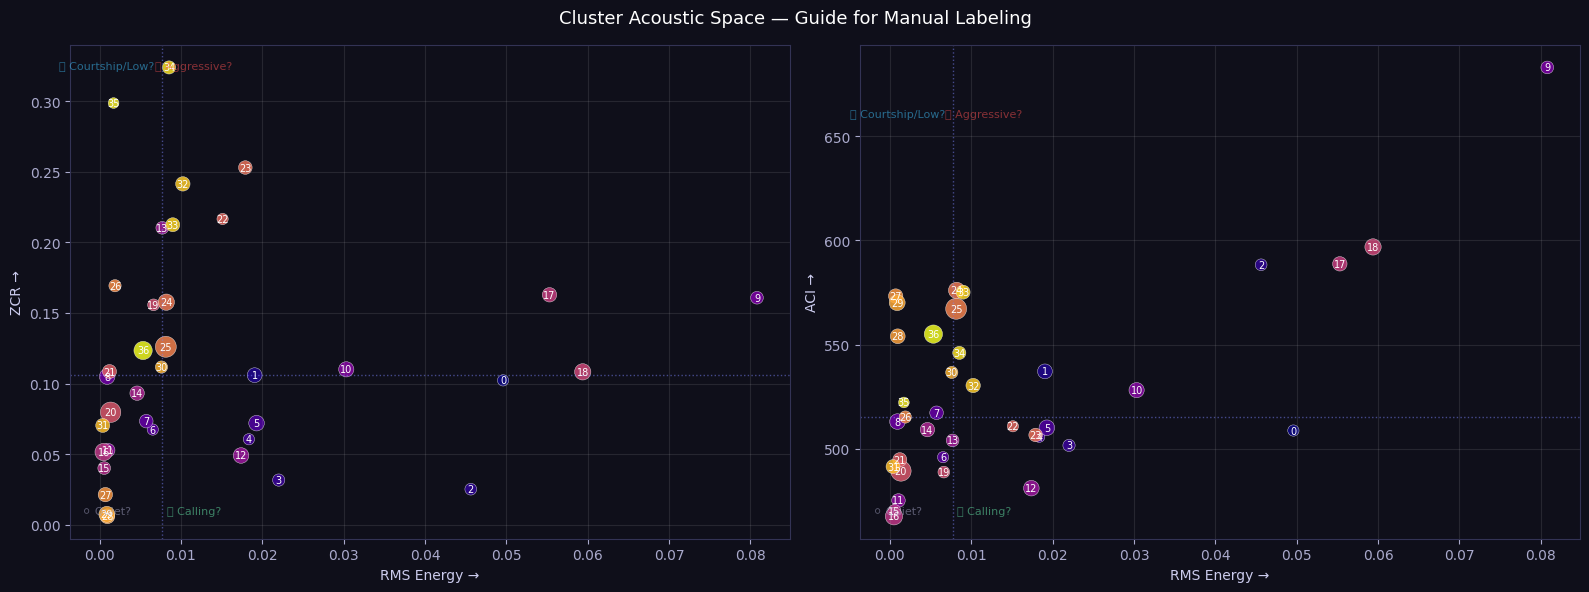

 Saved → results/05_cluster_acoustic_space.png


In [2]:
# ── Overview scatter: RMS vs ZCR ──────────────────────────────────────────────
stats_df = pd.DataFrame([
    {
        'cluster': cid,
        'rms': s['rms_mean'],
        'aci': s['aci_mean'],
        'zcr': s['zcr_mean'],
        'count': s['count'],
        'species': s['dom_species'],
    }
    for cid, s in cluster_stats.items()
])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Cluster Acoustic Space — Guide for Manual Labeling', fontsize=13, color='white')

for ax, (xcol, ycol, xlabel, ylabel, xhigh_label, yhigh_label) in zip(axes, [
    ('rms', 'zcr', 'RMS Energy →', 'ZCR →', 'Loud', 'High freq / noisy'),
    ('rms', 'aci', 'RMS Energy →', 'ACI →', 'Loud', 'Complex'),
]):
    sc = ax.scatter(
        stats_df[xcol], stats_df[ycol],
        s=stats_df['count'] * 6, c=stats_df['cluster'],
        cmap='plasma', alpha=0.85, edgecolors='white', linewidths=0.3
    )
    for _, row in stats_df.iterrows():
        ax.annotate(str(int(row['cluster'])),
                    (row[xcol], row[ycol]),
                    fontsize=7, color='white', ha='center', va='center')
    
    # Quadrant labels
    xm, ym = stats_df[xcol].median(), stats_df[ycol].median()
    ax.axvline(xm, color='#7c85ff', ls=':', lw=1, alpha=0.5)
    ax.axhline(ym, color='#7c85ff', ls=':', lw=1, alpha=0.5)
    
    # Quadrant annotations
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    quad_style = dict(fontsize=8, alpha=0.5, ha='center')
    ax.text(xm * 0.4 + xlim[0] * 0.6, ylim[1] * 0.95, '🔵 Courtship/Low?', color='#40c4ff', **quad_style)
    ax.text(xm * 1.5,                  ylim[1] * 0.95, '🔴 Aggressive?',    color='#ff5252', **quad_style)
    ax.text(xm * 0.4 + xlim[0] * 0.6, ylim[0] + (ylim[1]-ylim[0]) * 0.05, '⚪ Quiet?',  color='#aaaacc', **quad_style)
    ax.text(xm * 1.5,                  ylim[0] + (ylim[1]-ylim[0]) * 0.05, '🟢 Calling?',color='#69f0ae', **quad_style)
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.15)

plt.tight_layout()
fig.savefig(RESULTS / '05_cluster_acoustic_space.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print(' Saved → results/05_cluster_acoustic_space.png')

## 2️⃣ Audio Explorer — ฟัง + Label แต่ละ Cluster

**วิธีใช้**:
1. เลือก Cluster ID จาก dropdown
2. ดู mel-spectrogram และ acoustic stats
3. กด ▶ เพื่อฟัง audio ตัวอย่าง 3 segment
4. เลือก Song Type แล้วกด **Save Label**

In [3]:
# ── Helper: load and extract segment from wav ─────────────────────────────────
def load_segment(row, sr=SR, dur=SEG_DUR):
    """Load a 2.5-second segment from the wav file."""
    wav_path = WAV_ROOT / row['file']
    try:
        y, _ = librosa.load(wav_path, sr=sr, offset=float(row['start_s']), duration=dur, mono=True)
        return y
    except Exception as e:
        print(f' Cannot load {wav_path}: {e}')
        return np.zeros(int(sr * dur))


def plot_segment_analysis(rows_sample, sr=SR):
    """Plot waveform + mel-spectrogram for up to 3 segments."""
    n = min(3, len(rows_sample))
    fig, axes = plt.subplots(2, n, figsize=(5 * n, 6))
    if n == 1:
        axes = axes.reshape(2, 1)
    
    for i, (_, row) in enumerate(rows_sample.head(n).iterrows()):
        y = load_segment(row)
        
        # Waveform
        ax_w = axes[0, i]
        t = np.linspace(0, len(y) / sr, len(y))
        ax_w.plot(t, y, color='#7c85ff', lw=0.5, alpha=0.8)
        ax_w.set_title(f'Seg {int(row["segment"])} — {row["species"][:18]}', color='white', fontsize=9)
        ax_w.set_xlabel('Time (s)', fontsize=8)
        ax_w.set_ylabel('Amplitude', fontsize=8)
        ax_w.axhline(0, color='#333355', lw=0.5)
        
        # Mel-spectrogram
        ax_m = axes[1, i]
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64, fmax=8000)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        img = librosa.display.specshow(mel_db, sr=sr, hop_length=512,
                                        x_axis='time', y_axis='mel',
                                        fmax=8000, ax=ax_m, cmap='magma')
        ax_m.set_title(f'Mel-Spectrogram', color='white', fontsize=9)
        ax_m.set_xlabel('Time (s)', fontsize=8)
        ax_m.set_ylabel('Hz', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    return [load_segment(row) for _, row in rows_sample.head(n).iterrows()]

print(' Helper functions ready')

 Helper functions ready


In [4]:
# ── Interactive Labeling Widget ───────────────────────────────────────────────

SONG_TYPES = [
    '🟢 Calling Song',
    '🔴 Aggressive Song',
    '🔵 Courtship/Low Song',
    '⚪ Quiet/Background',
    '❓ Uncertain / Mixed',
    '🔇 Noise (not cricket)',
]

# UI Widgets
cluster_dropdown = widgets.Dropdown(
    options=all_cluster_ids,
    description='Cluster:',
    layout=widgets.Layout(width='200px'),
    style={'description_width': '60px'},
)

song_type_radio = widgets.RadioButtons(
    options=SONG_TYPES,
    description='Song Type:',
    layout=widgets.Layout(width='300px'),
    style={'description_width': '80px'},
)

notes_text = widgets.Textarea(
    placeholder='Notes (optional): e.g. "irregular burst pattern", "constant trill"...',
    layout=widgets.Layout(width='400px', height='60px'),
)

save_btn   = widgets.Button(description=' Save Label', button_style='success',
                             layout=widgets.Layout(width='140px'))
next_btn   = widgets.Button(description=' Next Cluster', button_style='info',
                             layout=widgets.Layout(width='140px'))
load_btn   = widgets.Button(description=' Load & Play', button_style='primary',
                             layout=widgets.Layout(width='140px'))

progress_label = widgets.Label(value='')
status_label   = widgets.Label(value='')
audio_out      = Output()
plot_out       = Output()
info_out       = Output()


def update_progress():
    done = len(manual_labels)
    total = len(all_cluster_ids)
    pct = done / total * 100
    progress_label.value = f'Progress: {done}/{total} clusters labeled ({pct:.0f}%)'


def on_load_click(_):
    cid = cluster_dropdown.value
    stats = cluster_stats[cid]
    rows = df[df['cluster'] == cid]
    
    # Pre-fill if already labeled
    if cid in manual_labels:
        existing = manual_labels[cid]['song_type']
        if existing in SONG_TYPES:
            song_type_radio.value = existing
        notes_text.value = manual_labels[cid].get('notes', '')
        status_label.value = f' Cluster {cid} already labeled as: {existing}'
    else:
        status_label.value = f' Cluster {cid} — not yet labeled'
    
    # Show info
    with info_out:
        clear_output(wait=True)
        print(f'═══════════════════════════════════════')
        print(f'  Cluster {cid}  ({stats["count"]} segments)')
        print(f'═══════════════════════════════════════')
        print(f'  RMS mean   : {stats["rms_mean"]:.5f}  (higher = louder)')
        print(f'  ACI mean   : {stats["aci_mean"]:.1f}  (higher = more complex)')
        print(f'  ZCR mean   : {stats["zcr_mean"]:.4f}  (higher = noisier/higher freq)')
        print(f'  Dom species: {stats["dom_species"]} ({stats["dom_purity"]:.0%} purity)')
        print(f'─ Acoustic Hints ──────────────────────')
        rms_rank = stats_df['rms'].rank(pct=True)[stats_df['cluster']==cid].values[0]
        aci_rank = stats_df['aci'].rank(pct=True)[stats_df['cluster']==cid].values[0]
        print(f'  RMS percentile: {rms_rank:.0%}  ', end='')
        print('← LOUD' if rms_rank > 0.75 else ('← quiet' if rms_rank < 0.25 else '← moderate'))
        print(f'  ACI percentile: {aci_rank:.0%}  ', end='')
        print('← COMPLEX' if aci_rank > 0.75 else ('← simple' if aci_rank < 0.25 else '← moderate'))
        
        # Song type hint
        if rms_rank > 0.75:
            print('  →  Likely Aggressive Song (high energy)')
        elif rms_rank < 0.25 and aci_rank > 0.5:
            print('  →  Possibly Courtship/Low (soft but complex)')
        elif rms_rank >= 0.25 and rms_rank <= 0.75 and aci_rank > 0.5:
            print('  →  Possibly Calling Song (moderate energy, complex)')
        else:
            print('  →  Possibly Quiet/Background')
        print(f'═══════════════════════════════════════')
    
    # Show spectrogram
    with plot_out:
        clear_output(wait=True)
        sample_rows = rows.sample(min(3, len(rows)), random_state=42)
        audios = plot_segment_analysis(sample_rows)
    
    # Play audio
    with audio_out:
        clear_output(wait=True)
        print(f' Playing {min(3, len(rows))} sample segments from Cluster {cid}:')
        for i, (audio, (_, row)) in enumerate(zip(audios, sample_rows.iterrows())):
            print(f'  [{i+1}] {row["file"][:60]}  (start={row["start_s"]}s)')
            display(ipd.Audio(audio, rate=SR, normalize=True))


def on_save_click(_):
    cid = cluster_dropdown.value
    song_type = song_type_radio.value
    notes = notes_text.value.strip()
    
    manual_labels[cid] = {
        'song_type': song_type,
        'notes':     notes,
        'cluster_id': cid,
    }
    
    # Save to JSON
    LABEL_FILE.write_text(json.dumps(manual_labels, indent=2, ensure_ascii=False))
    
    status_label.value = f' Saved: Cluster {cid} → {song_type}'
    update_progress()


def on_next_click(_):
    """Jump to next unlabeled cluster."""
    current = cluster_dropdown.value
    unlabeled = [c for c in all_cluster_ids if c not in manual_labels]
    if not unlabeled:
        status_label.value = ' All clusters labeled!'
        return
    # Find next unlabeled after current
    candidates = [c for c in unlabeled if c > current]
    next_cid = candidates[0] if candidates else unlabeled[0]
    cluster_dropdown.value = next_cid
    on_load_click(None)


load_btn.on_click(on_load_click)
save_btn.on_click(on_save_click)
next_btn.on_click(on_next_click)

update_progress()

# ── Layout ────────────────────────────────────────────────────────────────────
controls = HBox([
    VBox([
        widgets.HTML('<b>Step 1: Select Cluster</b>'),
        cluster_dropdown,
        load_btn,
    ]),
    VBox([
        widgets.HTML('<b>Step 2: Choose Song Type</b>'),
        song_type_radio,
    ]),
    VBox([
        widgets.HTML('<b>Step 3: Notes & Save</b>'),
        notes_text,
        HBox([save_btn, next_btn]),
    ]),
])

display(VBox([
    widgets.HTML('<h3>🎧 Cricket Cluster Audio Explorer</h3>'),
    controls,
    progress_label,
    status_label,
    info_out,
    plot_out,
    audio_out,
]))

## 3️⃣ Quick Batch: ดู Spectrogram ทุก Cluster พร้อมกัน

ใช้สำหรับ overview ก่อน label — เรียงตาม RMS (สูง → ต่ำ)

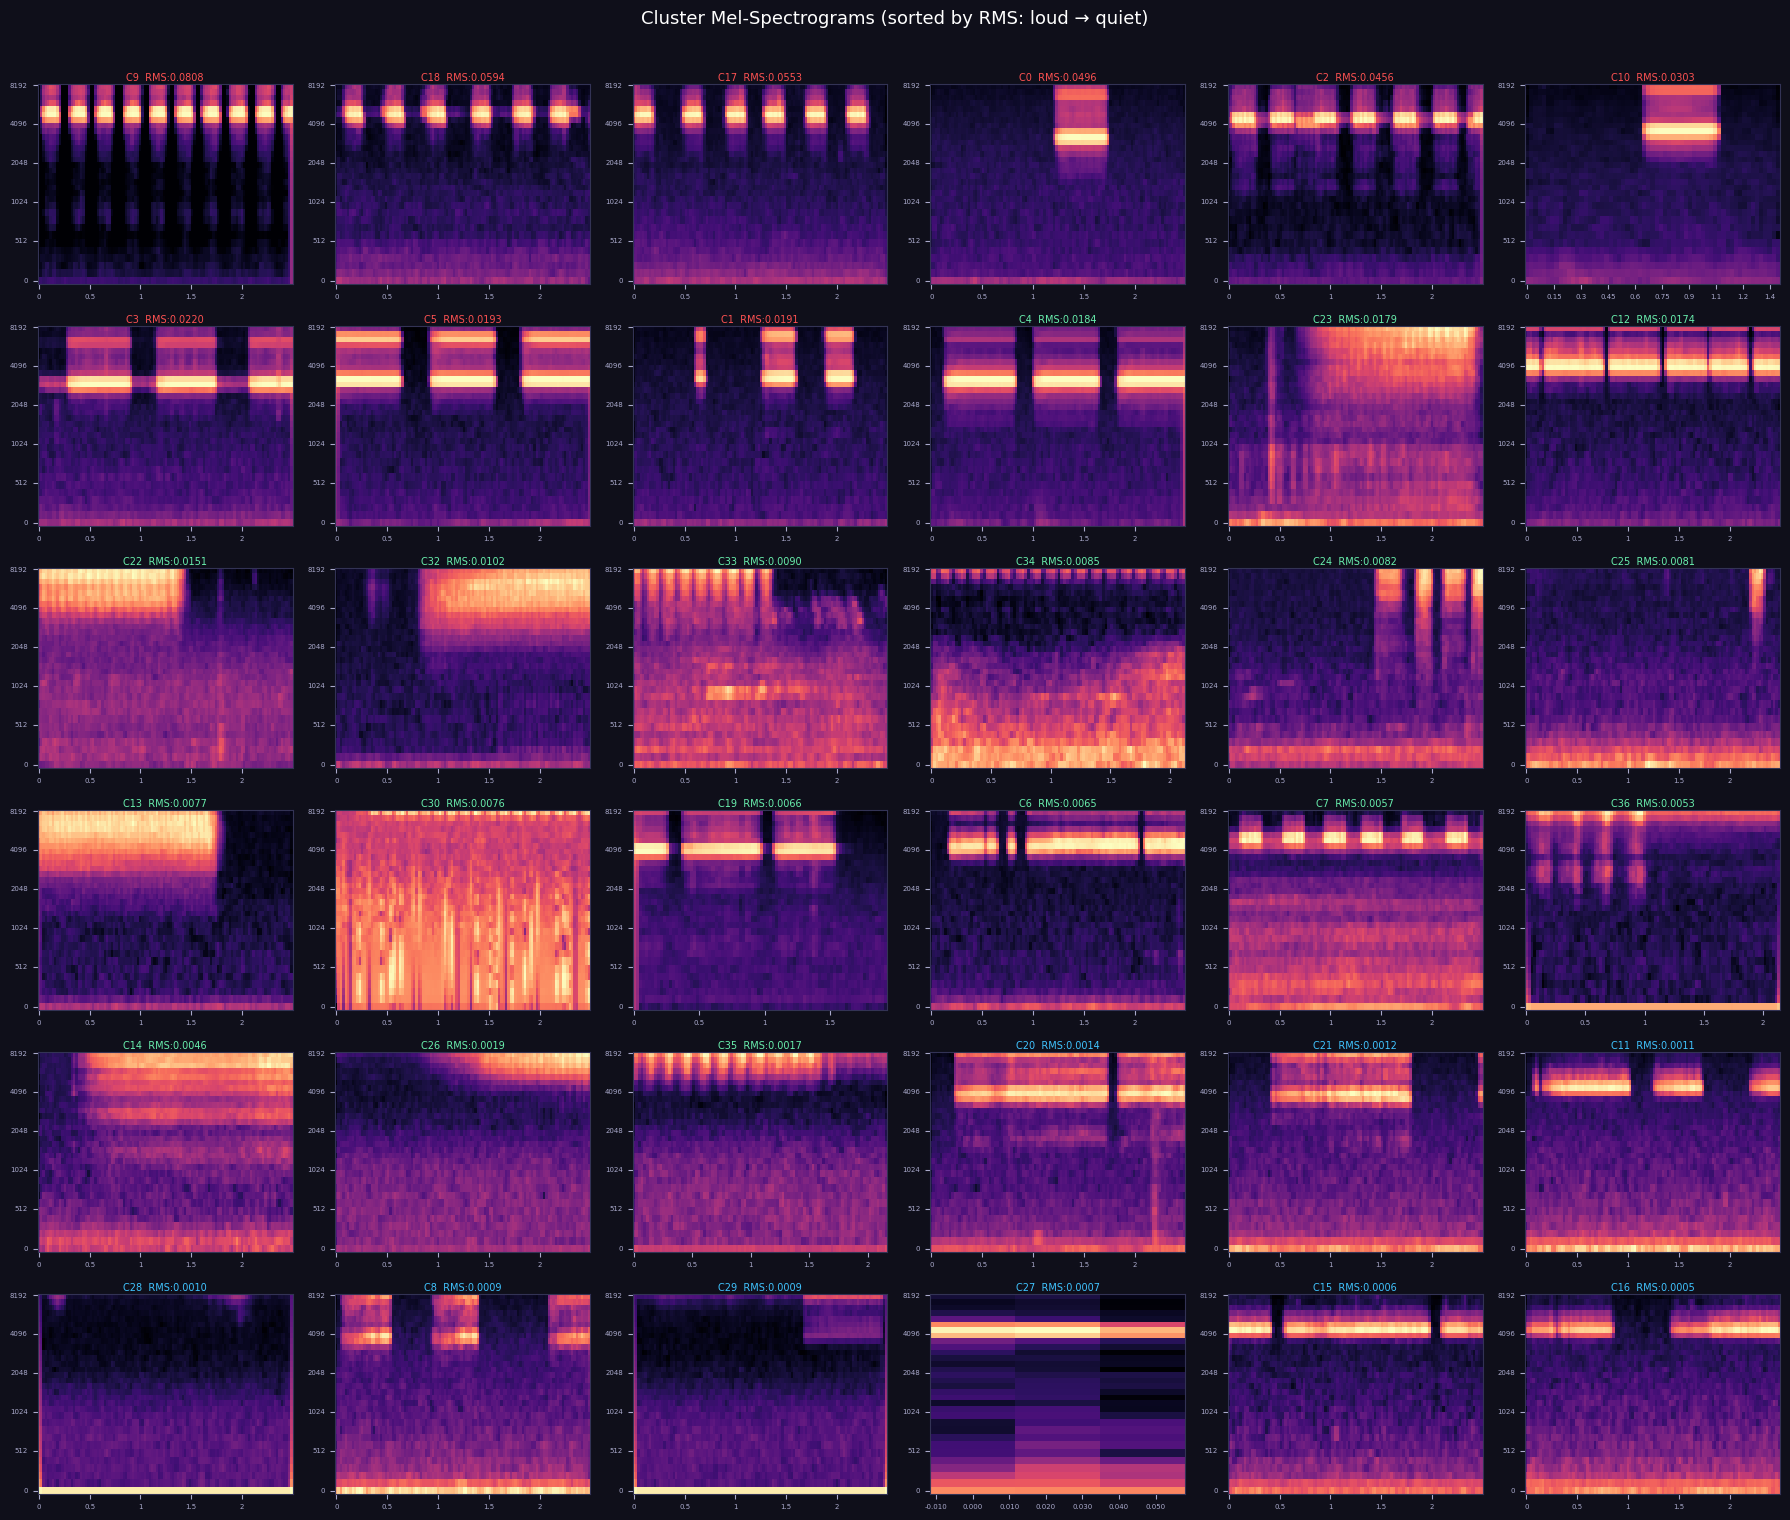

 Saved → results/05_cluster_spectrograms_gallery.png


In [5]:
# ── Batch spectrogram gallery (top representative per cluster) ────────────────
# เรียงตาม RMS สูง → ต่ำ เพื่อเห็น pattern ชัด
sorted_clusters = sorted(all_cluster_ids,
                          key=lambda c: cluster_stats[c]['rms_mean'], reverse=True)

N_SHOW = min(36, len(sorted_clusters))  # แสดงสูงสุด 36 clusters
N_COLS = 6
N_ROWS = (N_SHOW + N_COLS - 1) // N_COLS

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(N_COLS * 3, N_ROWS * 2.5))
fig.suptitle('Cluster Mel-Spectrograms (sorted by RMS: loud → quiet)',
             fontsize=13, color='white', y=1.01)
axes_flat = axes.flatten()

for i, cid in enumerate(sorted_clusters[:N_SHOW]):
    ax = axes_flat[i]
    stats = cluster_stats[cid]
    
    # Load representative segment (centroid = closest to cluster mean in UMAP space)
    cluster_emb = embedding[df['cluster'] == cid]
    centroid    = cluster_emb.mean(axis=0)
    dists       = np.linalg.norm(cluster_emb - centroid, axis=1)
    best_local  = np.argmin(dists)
    best_global = df[df['cluster'] == cid].index[best_local]
    rep_row     = df.loc[best_global]
    
    y = load_segment(rep_row)
    mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=32, fmax=8000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    
    librosa.display.specshow(mel_db, sr=SR, hop_length=512,
                              x_axis='time', y_axis='mel', fmax=8000,
                              ax=ax, cmap='magma')
    
    # Title with manual label if available
    label_str = ''
    if cid in manual_labels:
        lt = manual_labels[cid]['song_type']
        emoji = lt.split()[0] if lt else ''
        label_str = f' {emoji}'
    
    title_color = '#ff5252' if stats['rms_mean'] > stats_df['rms'].quantile(0.75) else \
                  '#69f0ae' if stats['rms_mean'] > stats_df['rms'].quantile(0.25) else '#40c4ff'
    
    ax.set_title(f'C{cid}{label_str}  RMS:{stats["rms_mean"]:.4f}',
                 fontsize=7, color=title_color, pad=2)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(labelsize=5)

# Hide unused axes
for j in range(N_SHOW, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
fig.savefig(RESULTS / '05_cluster_spectrograms_gallery.png', dpi=120, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print(' Saved → results/05_cluster_spectrograms_gallery.png')

## 4️⃣ Export Manual Labels → ใช้ใน BehaviorMonitor

In [6]:
# ── Summary of labels so far ──────────────────────────────────────────────────
if not manual_labels:
    print(' No labels saved yet — run the interactive widget above first')
else:
    label_df = pd.DataFrame([
        {
            'cluster':   cid,
            'song_type': v['song_type'],
            'notes':     v.get('notes', ''),
            'rms_mean':  cluster_stats[cid]['rms_mean'],
            'aci_mean':  cluster_stats[cid]['aci_mean'],
            'count':     cluster_stats[cid]['count'],
            'dom_species': cluster_stats[cid]['dom_species'],
        }
        for cid, v in manual_labels.items()
    ]).sort_values('cluster')
    
    print(' Manual Label Summary:')
    print(label_df['song_type'].value_counts().to_string())
    print()
    display(label_df)
    
    # Generate BehaviorMonitor config
    aggressive_ids = [cid for cid, v in manual_labels.items() if 'Aggressive' in v['song_type']]
    calling_ids    = [cid for cid, v in manual_labels.items() if 'Calling' in v['song_type']]
    
    print(f'\n BehaviorMonitor config (paste into notebook 04):')
    print(f'   aggressive_cluster_ids = {aggressive_ids}')
    print(f'   calling_cluster_ids    = {calling_ids}')
    
    # Save labeled CSV
    label_df.to_csv(RESULTS / '05_manual_cluster_labels.csv', index=False)
    print(f'\n Saved → results/05_manual_cluster_labels.csv')

 No labels saved yet — run the interactive widget above first


---

## 📖 Reference Guide สำหรับ Labeling

### ดู Spectrogram แล้วหา Pattern นี้:

| Pattern ที่เห็นใน Spectrogram | Song Type |
|-------------------------------|----------|
| **Regular pulse trains** + energy กระจุกที่ 3-8 kHz | 🟢 Calling Song |
| **Irregular bursts** + energy สูงทั้ง spectrum | 🔴 Aggressive Song |
| **Continuous soft trill** + energy ต่ำ < 5 kHz | 🔵 Courtship Song |
| **Sparse energy** + noise floor เท่านั้น | ⚪ Quiet/Background |
| **Broadband continuous** + no clear pattern | 🔇 Noise |

### Gryllus campestris (European Field Cricket) — Species ใน Dataset
- **Calling Song**: ~3-4 chirps/sec, carrier frequency ~4.5 kHz
- **Aggressive Song**: shorter, faster pulses, more irregular
- **Courtship Song**: quieter, longer intervals

> 📚 **Reference**: Huber, F., & Thorson, J. (1985). Cricket auditory communication. *Scientific American*, 253(6), 60-68.